# Problem Statement
Indian Premier League (IPL) is a league for Twenty20 (T20) cricket championships started in India. The auction price of the player depends on his performance in test matches or one-day internationals. The primary skill of the player also contributes to the auction price. We use different regression techniques to predict the auction price of the player.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from warnings import filterwarnings

filterwarnings("ignore")

from sklearn.model_selection import train_test_split
import statsmodels
import statsmodels.api as sm
from scipy import stats
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import StandardScaler


In [ ]:
df_ipl = pd.read_csv(r"ipl_player_auction.csv")
df_ipl.head()


,PLAYER NAME,AGE,COUNTRY,PLAYING ROLE,T-RUNS,T-WKTS,ODI-RUNS-S,ODI-SR-B,ODI-WKTS,ODI-SR-BL,CAPTAINCY EXP,RUNS-S,HS,AVE,SR-B,SIXERS,RUNS-C,WKTS,AVE-BL,ECON,SR-BL,SOLD PRICE
0,Abdulla,2,South Africa,Allrounder,0,0,0,0.00,0,0.0,0,0,0,0.00,0.00,0,307,15,20.47,9.90,13.93,50000
1,Abdur Razzak,2,Bangladesh,Bowler,266,18,657,71.41,185,37.6,0,0,0,0.00,0.00,0,29,0,0.00,17.50,0.00,50000
2,Agarkar,2,India,Bowler,669,58,1269,80.62,288,32.9,0,167,39,18.56,121.01,5,1059,29,36.52,8.81,24.90,350000
3,Ashwin,1,India,Bowler,308,31,241,84.56,51,36.8,0,58,11,5.80,76.32,0,1125,49,22.96,8.23,22.14,850000
4,Badrinath,2,India,Batsman,109,0,79,45.93,0,0.0,0,1317,71,32.93,120.71,28,0,0,0.00,1.00,0.00,800000


In [ ]:
df_ipl.shape


(130, 22)

In [ ]:
df_ipl.dtypes


PLAYER NAME       object
AGE                int64
COUNTRY           object
PLAYING ROLE      object
T-RUNS             int64
T-WKTS             int64
ODI-RUNS-S         int64
ODI-SR-B         float64
ODI-WKTS           int64
ODI-SR-BL        float64
CAPTAINCY EXP      int64
RUNS-S             int64
HS                 int64
AVE              float64
SR-B             float64
SIXERS             int64
RUNS-C             int64
WKTS               int64
AVE-BL           float64
ECON             float64
SR-BL            float64
SOLD PRICE         int64
dtype: object

In [ ]:
df_ipl["AGE"] = df_ipl["AGE"].astype("object")

df_ipl["CAPTAINCY EXP"] = df_ipl["CAPTAINCY EXP"].astype("object")


In [ ]:
df_ipl.dtypes


PLAYER NAME       object
AGE               object
COUNTRY           object
PLAYING ROLE      object
T-RUNS             int64
T-WKTS             int64
ODI-RUNS-S         int64
ODI-SR-B         float64
ODI-WKTS           int64
ODI-SR-BL        float64
CAPTAINCY EXP     object
RUNS-S             int64
HS                 int64
AVE              float64
SR-B             float64
SIXERS             int64
RUNS-C             int64
WKTS               int64
AVE-BL           float64
ECON             float64
SR-BL            float64
SOLD PRICE         int64
dtype: object

In [ ]:
df_ipl.drop("PLAYER NAME", axis=1, inplace=True)


In [ ]:
df_ipl.isnull().sum()


AGE              0
COUNTRY          0
PLAYING ROLE     0
T-RUNS           0
T-WKTS           0
ODI-RUNS-S       0
ODI-SR-B         0
ODI-WKTS         0
ODI-SR-BL        0
CAPTAINCY EXP    0
RUNS-S           0
HS               0
AVE              0
SR-B             0
SIXERS           0
RUNS-C           0
WKTS             0
AVE-BL           0
ECON             0
SR-BL            0
SOLD PRICE       0
dtype: int64

In [ ]:
df_target = df_ipl["SOLD PRICE"]
df_features = df_ipl.drop("SOLD PRICE", axis=1)


In [ ]:
df_num_features = df_features.select_dtypes(include=int)
df_num_features.columns


Index(['T-RUNS', 'T-WKTS', 'ODI-RUNS-S', 'ODI-WKTS', 'RUNS-S', 'HS', 'SIXERS',
       'RUNS-C', 'WKTS'],
      dtype='object')

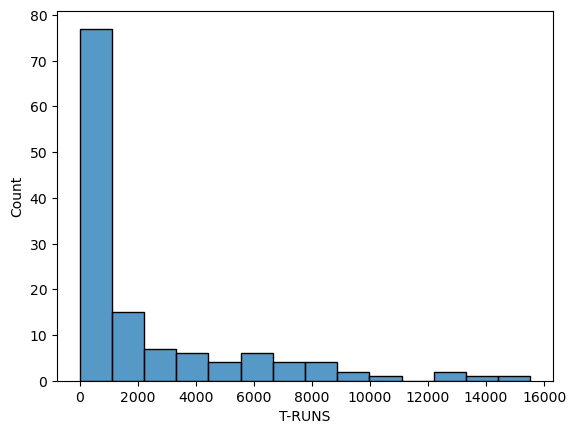

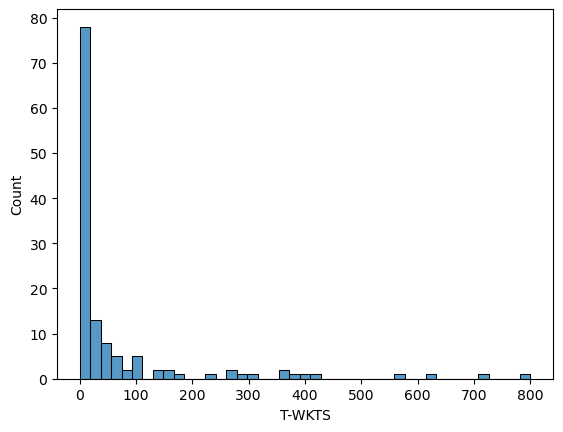

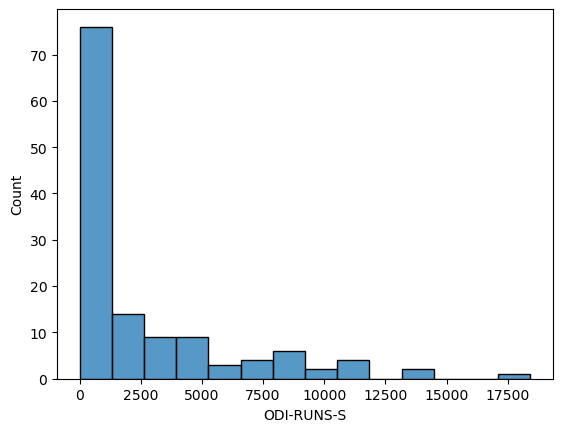

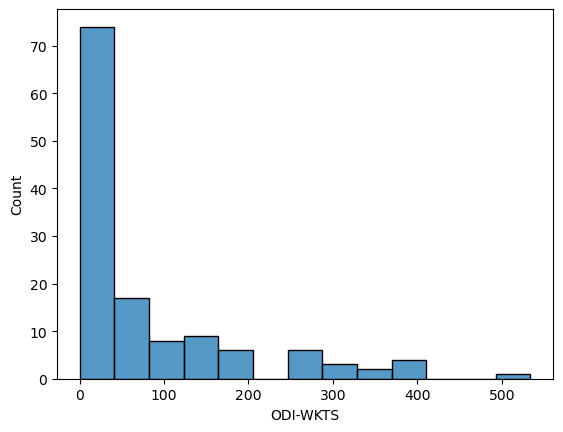

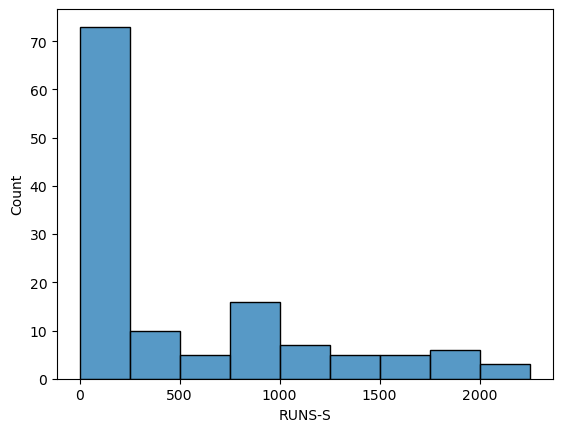

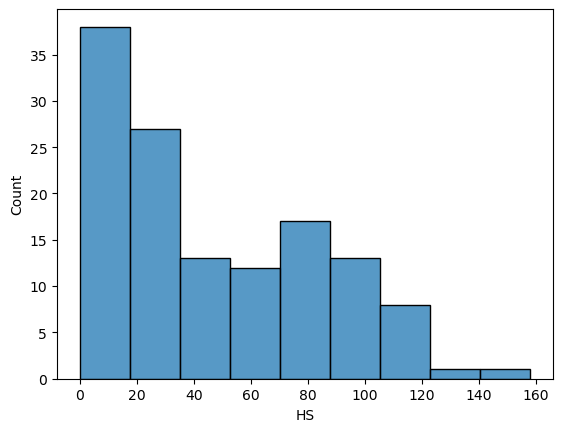

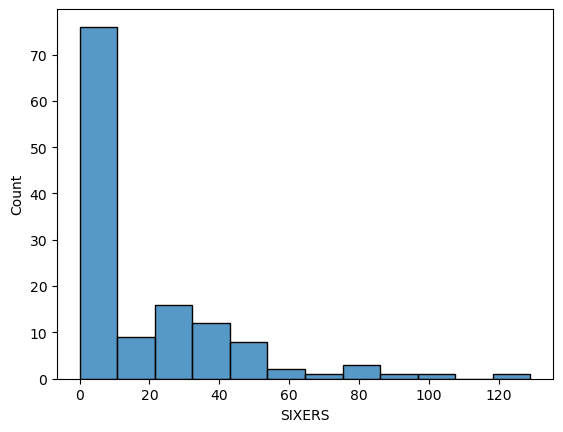

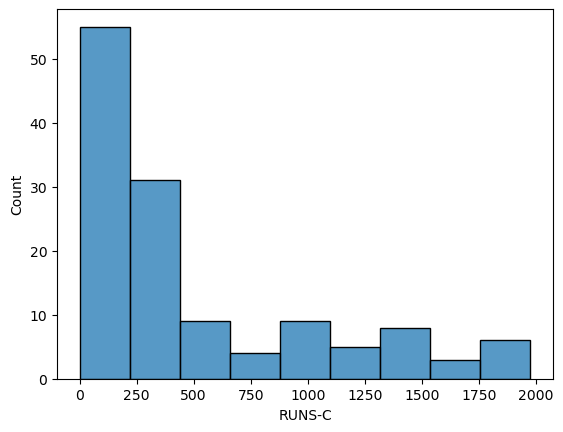

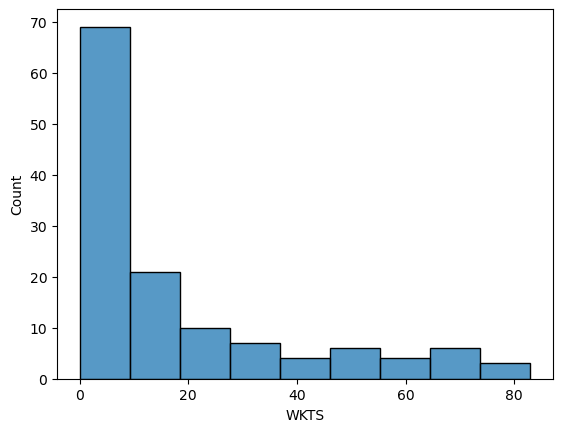

In [ ]:
for i in df_num_features.columns:
    sns.histplot(data=df_num_features, x=i)
    plt.show()


In [ ]:
df_cat_features = df_features.select_dtypes(include=object)
df_cat_features.columns


Index(['AGE', 'COUNTRY', 'PLAYING ROLE', 'CAPTAINCY EXP'], dtype='object')

In [ ]:
dammy_var = pd.get_dummies(data=df_cat_features, drop_first=True)
dammy_var.columns


Index(['AGE_2', 'AGE_3', 'COUNTRY_Bangladesh', 'COUNTRY_England',
       'COUNTRY_India', 'COUNTRY_New Zealand', 'COUNTRY_Pakistan',
       'COUNTRY_South Africa', 'COUNTRY_Sri Lanka', 'COUNTRY_West Indies',
       'COUNTRY_Zimbabwe', 'PLAYING ROLE_Batsman', 'PLAYING ROLE_Bowler',
       'PLAYING ROLE_W. Keeper', 'CAPTAINCY EXP_1'],
      dtype='object')

In [ ]:
X_scaler = StandardScaler()

num_scaled = X_scaler.fit_transform(df_num_features)

df_num_scaled = pd.DataFrame(num_scaled, columns=df_num_features.columns)


In [ ]:
y = (df_target - df_target.mean()) / df_target.std()

y.head()


0   -1.158345
1   -1.158345
2   -0.420895
3    0.808188
4    0.685280
Name: SOLD PRICE, dtype: float64

In [ ]:
X = pd.concat([df_num_scaled, dammy_var], axis=1)

X.head()


,T-RUNS,T-WKTS,ODI-RUNS-S,ODI-WKTS,RUNS-S,HS,SIXERS,RUNS-C,WKTS,AGE_2,AGE_3,COUNTRY_Bangladesh,COUNTRY_England,COUNTRY_India,COUNTRY_New Zealand,COUNTRY_Pakistan,COUNTRY_South Africa,COUNTRY_Sri Lanka,COUNTRY_West Indies,COUNTRY_Zimbabwe,PLAYING ROLE_Batsman,PLAYING ROLE_Bowler,PLAYING ROLE_W. Keeper,CAPTAINCY EXP_1
0,-0.674581,-0.468108,-0.703043,-0.686760,-0.839014,-1.307954,-0.745369,-0.303010,-0.096956,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False
1,-0.593774,-0.341460,-0.518927,0.983269,-0.839014,-1.307954,-0.745369,-0.802864,-0.786968,True,False,True,False,False,False,False,False,False,False,False,False,True,False,False
2,-0.471347,-0.060022,-0.347421,1.913068,-0.566677,-0.232487,-0.534721,1.049112,0.547056,True,False,False,False,True,False,False,False,False,False,False,False,True,False,False
3,-0.581015,-0.249993,-0.635505,-0.226374,-0.744430,-1.004617,-0.745369,1.167783,1.467072,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False
4,-0.641468,-0.468108,-0.680904,-0.686760,1.308699,0.649946,0.434258,-0.855007,-0.786968,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=10, test_size=0.2
)
print("X_train", X_train.shape)
print("y_train", y_train.shape)


print("X_test", X_test.shape)
print("y_test", y_test.shape)


X_train (104, 24)
y_train (104,)
X_test (26, 24)
y_test (26,)


In [ ]:
def get_train_rmse(model):

    train_pred = model.predict(X_train)
    mse_train = mean_squared_error(y_train, train_pred)

    rmse_train = round(np.sqrt(mse_train), 4)

    return rmse_train


In [ ]:
def get_test_rmse(model):

    test_pred = model.predict(X_test)
    mse_test = mean_squared_error(y_test, test_pred)
    rmse_test = round(np.sqrt(mse_test), 4)

    return rmse_test


In [ ]:
def mape(actual, predicted):
    return np.mean(np.abs((actual - predicted) / actual)) * 100


def get_test_mape(model):
    test_pred = model.predict(X_test)
    mape_test = mape(y_test, test_pred)

    return mape_test


In [ ]:
def get_score(model):

    r_sq = model.score(X_train, y_train)

    n = X_train.shape[0]

    k = X_train.shape[1]

    r_sq_adj = 1 - ((1 - r_sq) * (n - 1) / (n - k - 1))

    return [r_sq, r_sq_adj]


In [ ]:
score_card = pd.DataFrame(
    columns=[
        "Model_Name",
        "Alpha (Wherever Required)",
        "l1-ratio",
        "R-Squared",
        "Adj. R-Squared",
        "Test_RMSE",
        "Test_MAPE",
    ]
)


def update_score_card(algorithm_name, model, alpha="-", l1_ratio="-"):
    global score_card
    new_row = pd.DataFrame(
        {
            "Model_Name": [algorithm_name],
            "Alpha (Wherever Required)": [alpha],
            "l1-ratio": [l1_ratio],
            "Test_MAPE": [get_test_mape(model)],
            "Test_RMSE": [get_test_rmse(model)],
            "R-Squared": [get_score(model)[0]],
            "Adj. R-Squared": [get_score(model)[1]],
        }
    )
    score_card = pd.concat([score_card, new_row], ignore_index=True)
    return score_card


In [ ]:
def plot_coefficients(model, algorithm_name):
    df_coeff = pd.DataFrame({"Variable": X.columns, "Coefficient": model.coef_})
    sorted_coeff = df_coeff.sort_values("Coefficient", ascending=False)
    sns.barplot(x="Coefficient", y="Variable", data=sorted_coeff)
    plt.xlabel("Coefficients from {}".format(algorithm_name), fontsize=15)

    plt.ylabel("Features", fontsize=15)


# Linear Regression

In [ ]:
linreg = LinearRegression()
MLR_model = linreg.fit(X_train, y_train)
MLR_model.score(X_train, y_train)


0.5652428702612089

In [ ]:
score_card = update_score_card(algorithm_name="Linear Regression", model=MLR_model)

score_card


,Model_Name,Alpha (Wherever Required),l1-ratio,R-Squared,Adj. R-Squared,Test_RMSE,Test_MAPE
0,Linear Regression,-,-,0.565243,0.433165,0.8886,155.021611


# Stochastic Gradient Descent

In [ ]:
sgd = SGDRegressor(random_state=10)
linreg_with_SGD = sgd.fit(X_train, y_train)
print("RMSE on train set:", get_train_rmse(linreg_with_SGD))
print("RMSE on test set:", get_test_rmse(linreg_with_SGD))


RMSE on train set: 0.7395
RMSE on test set: 0.8226


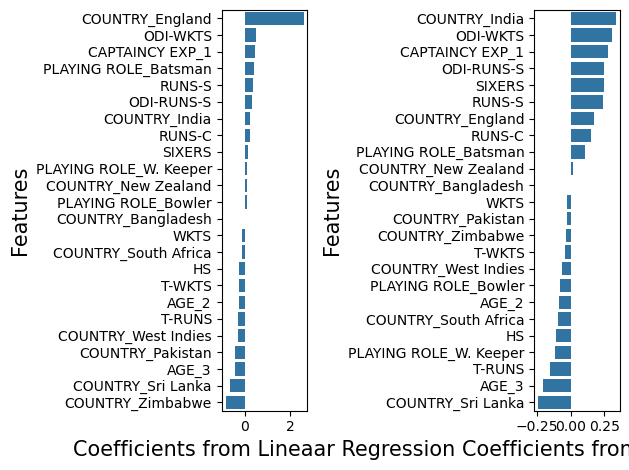

In [ ]:
plt.subplot(1, 2, 1)
plot_coefficients(MLR_model, "Lineaar Regression")

plt.subplot(1, 2, 2)
plot_coefficients(linreg_with_SGD, "SGD")

plt.tight_layout()
plt.show()


In [ ]:
update_score_card(algorithm_name="Linear Regression (using SGD)", model=linreg_with_SGD)
score_card


,Model_Name,Alpha (Wherever Required),l1-ratio,R-Squared,Adj. R-Squared,Test_RMSE,Test_MAPE
0,Linear Regression,-,-,0.565243,0.433165,0.8886,155.021611
1,Linear Regression (using SGD),-,-,0.479010,0.320735,0.8226,166.158820


# Regularization

## 1. Ridge

In [ ]:
ridge = Ridge(alpha=1, max_iter=500)
ridge.fit(X_train, y_train)


Ridge(alpha=1, max_iter=500)

In [ ]:
update_score_card(
    algorithm_name="Ridge Regression (with alpha = 1)", model=ridge, alpha=1
)

score_card


,Model_Name,Alpha (Wherever Required),l1-ratio,R-Squared,Adj. R-Squared,Test_RMSE,Test_MAPE
0,Linear Regression,-,-,0.565243,0.433165,0.8886,155.021611
1,Linear Regression (using SGD),-,-,0.479010,0.320735,0.8226,166.158820
2,Ridge Regression (with alpha = 1),1,-,0.546676,0.408957,0.8034,181.451557


In [ ]:
ridge_2 = Ridge(alpha=2, max_iter=500)
ridge_2.fit(X_train, y_train)


Ridge(alpha=2, max_iter=500)

In [ ]:
update_score_card(
    algorithm_name="Ridge Regression (with alpha = 2)", model=ridge_2, alpha="2"
)
score_card


,Model_Name,Alpha (Wherever Required),l1-ratio,R-Squared,Adj. R-Squared,Test_RMSE,Test_MAPE
0,Linear Regression,-,-,0.565243,0.433165,0.8886,155.021611
1,Linear Regression (using SGD),-,-,0.479010,0.320735,0.8226,166.158820
2,Ridge Regression (with alpha = 1),1,-,0.546676,0.408957,0.8034,181.451557
3,Ridge Regression (with alpha = 2),2,-,0.531388,0.389025,0.8027,181.578491


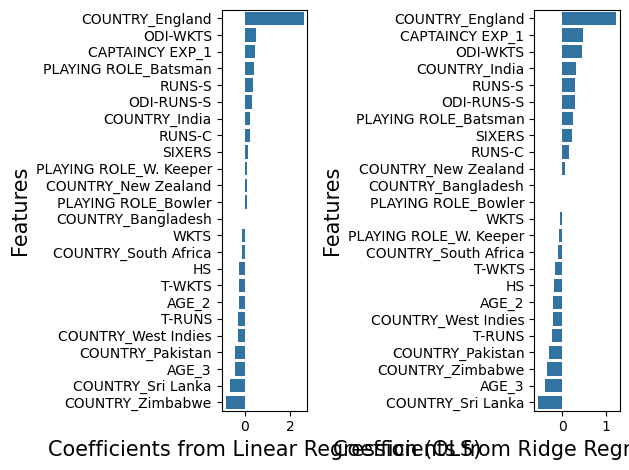

In [ ]:
plt.subplot(1, 2, 1)
plot_coefficients(MLR_model, "Linear Regression (OLS)")
plt.subplot(1, 2, 2)
plot_coefficients(ridge, "Ridge Regression (alpha = 2)")
plt.tight_layout()
plt.show()


# 2. Lasso

In [ ]:
lasso = Lasso(alpha=0.01, max_iter=500)
lasso.fit(X_train, y_train)


Lasso(alpha=0.01, max_iter=500)

In [ ]:
update_score_card(algorithm_name="Lasso Regression", model=lasso, alpha="0.01")
score_card


,Model_Name,Alpha (Wherever Required),l1-ratio,R-Squared,Adj. R-Squared,Test_RMSE,Test_MAPE
0,Linear Regression,-,-,0.565243,0.433165,0.8886,155.021611
1,Linear Regression (using SGD),-,-,0.479010,0.320735,0.8226,166.158820
2,Ridge Regression (with alpha = 1),1,-,0.546676,0.408957,0.8034,181.451557
3,Ridge Regression (with alpha = 2),2,-,0.531388,0.389025,0.8027,181.578491
4,Lasso Regression,0.01,-,0.533108,0.391267,0.8059,181.715448


In [ ]:
df_lasso_coeff = pd.DataFrame({"Variable": X.columns, "Coefficient": lasso.coef_})

print("Insignificant variables obtained from Lasso Regression when alpha is 0.01")
df_lasso_coeff.Variable[df_lasso_coeff.Coefficient == 0].to_list()


Insignificant variables obtained from Lasso Regression when alpha is 0.01


['WKTS',
 'COUNTRY_Bangladesh',
 'COUNTRY_New Zealand',
 'COUNTRY_Pakistan',
 'COUNTRY_South Africa',
 'COUNTRY_West Indies',
 'COUNTRY_Zimbabwe',
 'PLAYING ROLE_Bowler']

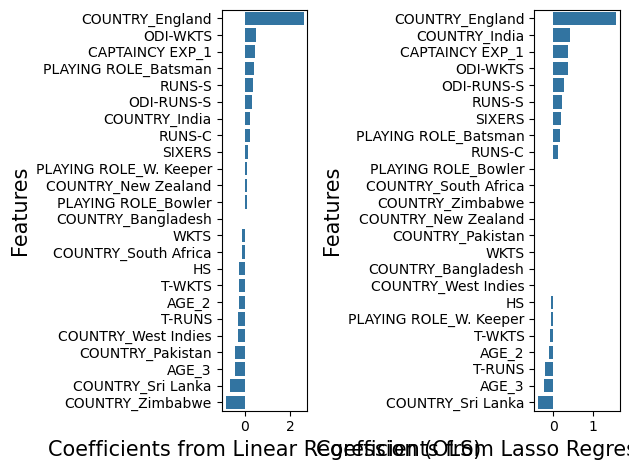

In [ ]:
plt.subplot(1, 2, 1)
plot_coefficients(MLR_model, "Linear Regression (OLS)")
plt.subplot(1, 2, 2)
plot_coefficients(lasso, "Lasso Regression (alpha = 0.01)")
plt.tight_layout()
plt.show()


# 3.Elastic net

In [ ]:
enet = ElasticNet(alpha=0.1, l1_ratio=0.01, max_iter=500)
enet.fit(X_train, y_train)


ElasticNet(alpha=0.1, l1_ratio=0.01, max_iter=500)

In [ ]:
update_score_card(
    algorithm_name="Elastic Net Regression", model=enet, alpha="0.1", l1_ratio="0.01"
)
score_card


,Model_Name,Alpha (Wherever Required),l1-ratio,R-Squared,Adj. R-Squared,Test_RMSE,Test_MAPE
0,Linear Regression,-,-,0.565243,0.433165,0.8886,155.021611
1,Linear Regression (using SGD),-,-,0.479010,0.320735,0.8226,166.158820
2,Ridge Regression (with alpha = 1),1,-,0.546676,0.408957,0.8034,181.451557
3,Ridge Regression (with alpha = 2),2,-,0.531388,0.389025,0.8027,181.578491
4,Lasso Regression,0.01,-,0.533108,0.391267,0.8059,181.715448
5,Elastic Net Regression,0.1,0.01,0.472897,0.312765,0.8017,156.486870


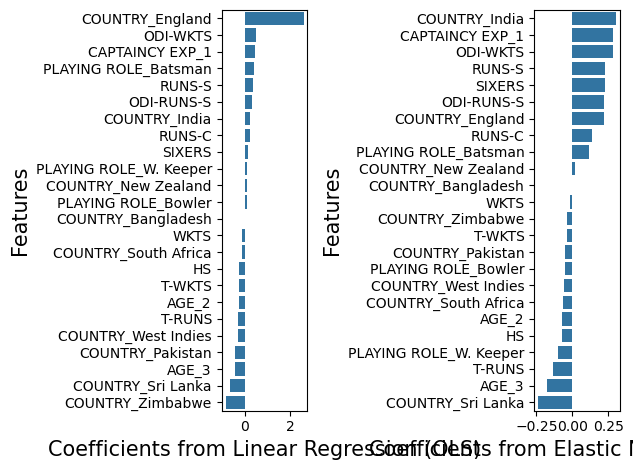

In [ ]:
plt.subplot(1, 2, 1)
plot_coefficients(MLR_model, "Linear Regression (OLS)")
plt.subplot(1, 2, 2)
plot_coefficients(enet, "Elastic Net Regression")
plt.tight_layout()

plt.show()


# Grid Search CV

## using ridge

In [ ]:
tuned_paramaters = [
    {
        "alpha": [
            1e-15,
            1e-10,
            1e-8,
            1e-4,
            1e-3,
            1e-2,
            0.1,
            1,
            5,
            10,
            20,
            40,
            60,
            80,
            100,
        ]
    }
]

ridge = Ridge()
ridge_grid = GridSearchCV(estimator=ridge, param_grid=tuned_paramaters, cv=10)

ridge_grid.fit(X_train, y_train)


GridSearchCV(cv=10, estimator=Ridge(),
             param_grid=[{'alpha': [1e-15, 1e-10, 1e-08, 0.0001, 0.001, 0.01,
                                    0.1, 1, 5, 10, 20, 40, 60, 80, 100]}])

In [ ]:
update_score_card(
    algorithm_name="Ridge Regression (using GridSearchCV)",
    model=ridge_grid,
    alpha=ridge_grid.best_params_.get("alpha"),
)

score_card


,Model_Name,Alpha (Wherever Required),l1-ratio,R-Squared,Adj. R-Squared,Test_RMSE,Test_MAPE
0,Linear Regression,-,-,0.565243,0.433165,0.8886,155.021611
1,Linear Regression (using SGD),-,-,0.479010,0.320735,0.8226,166.158820
2,Ridge Regression (with alpha = 1),1,-,0.546676,0.408957,0.8034,181.451557
3,Ridge Regression (with alpha = 2),2,-,0.531388,0.389025,0.8027,181.578491
4,Lasso Regression,0.01,-,0.533108,0.391267,0.8059,181.715448
5,Elastic Net Regression,0.1,0.01,0.472897,0.312765,0.8017,156.486870
6,Ridge Regression (using GridSearchCV),10,-,0.476918,0.318007,0.8013,154.262209


## Using LASSO

In [ ]:
tuned_paramaters = [
    {"alpha": [1e-15, 1e-10, 1e-8, 0.0001, 0.001, 0.01, 0.1, 1, 5, 10, 20]}
]

lasso = Lasso()

lasso_grid = GridSearchCV(estimator=lasso, param_grid=tuned_paramaters, cv=10)

lasso_grid.fit(X_train, y_train)


GridSearchCV(cv=10, estimator=Lasso(),
             param_grid=[{'alpha': [1e-15, 1e-10, 1e-08, 0.0001, 0.001, 0.01,
                                    0.1, 1, 5, 10, 20]}])

In [ ]:
update_score_card(
    algorithm_name="Lasso Regression (using GridSearchCV)",
    model=lasso_grid,
    alpha=lasso_grid.best_params_.get("alpha"),
)

score_card


,Model_Name,Alpha (Wherever Required),l1-ratio,R-Squared,Adj. R-Squared,Test_RMSE,Test_MAPE
0,Linear Regression,-,-,0.565243,0.433165,0.8886,155.021611
1,Linear Regression (using SGD),-,-,0.479010,0.320735,0.8226,166.158820
2,Ridge Regression (with alpha = 1),1,-,0.546676,0.408957,0.8034,181.451557
3,Ridge Regression (with alpha = 2),2,-,0.531388,0.389025,0.8027,181.578491
4,Lasso Regression,0.01,-,0.533108,0.391267,0.8059,181.715448
5,Elastic Net Regression,0.1,0.01,0.472897,0.312765,0.8017,156.486870
6,Ridge Regression (using GridSearchCV),10,-,0.476918,0.318007,0.8013,154.262209
7,Lasso Regression (using GridSearchCV),0.01,-,0.533108,0.391267,0.8059,181.715448


## Elastic Net

In [ ]:
tuned_paramaters = [
    {
        "alpha": [0.0001, 0.001, 0.01, 0.1, 1, 5, 10, 20, 40, 60],
        "l1_ratio": [0.0001, 0.0002, 0.001, 0.01, 0.1, 0.2],
    }
]

enet = ElasticNet()

enet_grid = GridSearchCV(estimator=enet, param_grid=tuned_paramaters, cv=10)
enet_grid.fit(X_train, y_train)


GridSearchCV(cv=10, estimator=ElasticNet(),
             param_grid=[{'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 5, 10, 20, 40,
                                    60],
                          'l1_ratio': [0.0001, 0.0002, 0.001, 0.01, 0.1, 0.2]}])

In [ ]:
update_score_card(
    algorithm_name="Elastic Net Regression (using GridSearchCV)",
    model=enet_grid,
    alpha=enet_grid.best_params_.get("alpha"),
    l1_ratio=enet_grid.best_params_.get("l1_ratio"),
)

score_card


,Model_Name,Alpha (Wherever Required),l1-ratio,R-Squared,Adj. R-Squared,Test_RMSE,Test_MAPE
0,Linear Regression,-,-,0.565243,0.433165,0.8886,155.021611
1,Linear Regression (using SGD),-,-,0.479010,0.320735,0.8226,166.158820
2,Ridge Regression (with alpha = 1),1,-,0.546676,0.408957,0.8034,181.451557
3,Ridge Regression (with alpha = 2),2,-,0.531388,0.389025,0.8027,181.578491
4,Lasso Regression,0.01,-,0.533108,0.391267,0.8059,181.715448
5,Elastic Net Regression,0.1,0.01,0.472897,0.312765,0.8017,156.486870
6,Ridge Regression (using GridSearchCV),10,-,0.476918,0.318007,0.8013,154.262209
7,Lasso Regression (using GridSearchCV),0.01,-,0.533108,0.391267,0.8059,181.715448
8,Elastic Net Regression (using GridSearchCV),0.1,0.0001,0.475095,0.315631,0.8008,154.390496


In [ ]:
score_card = score_card.sort_values("Test_RMSE").reset_index(drop=True)

score_card.style.highlight_min(color="lightblue", subset="Test_RMSE")


,Model_Name,Alpha (Wherever Required),l1-ratio,R-Squared,Adj. R-Squared,Test_RMSE,Test_MAPE
0,Elastic Net Regression (using GridSearchCV),0.100000,0.000100,0.475095,0.315631,0.800800,154.390496
1,Ridge Regression (using GridSearchCV),10,-,0.476918,0.318007,0.801300,154.262209
2,Elastic Net Regression,0.1,0.01,0.472897,0.312765,0.801700,156.486870
3,Ridge Regression (with alpha = 2),2,-,0.531388,0.389025,0.802700,181.578491
4,Ridge Regression (with alpha = 1),1,-,0.546676,0.408957,0.803400,181.451557
5,Lasso Regression,0.01,-,0.533108,0.391267,0.805900,181.715448
6,Lasso Regression (using GridSearchCV),0.010000,-,0.533108,0.391267,0.805900,181.715448
7,Linear Regression (using SGD),-,-,0.479010,0.320735,0.822600,166.158820
8,Linear Regression,-,-,0.565243,0.433165,0.888600,155.021611
